"""
Advanced Analytics Module.

This script performs advanced risk and investor
analytics including VaR, CVaR, Rolling Sharpe Ratio,
Investor Cohort Analysis, SIP Continuity Analysis,
Fund Recommendation System, and Portfolio
Concentration (HHI) analysis.
"""

In [2]:
import pandas as pd
import numpy as np

nav_df = pd.read_csv('../data/raw/02_nav_history.csv', parse_dates=['date'])
fund_df = pd.read_csv('../data/raw/01_fund_master.csv')

# Check actual column names
print("NAV columns:", nav_df.columns.tolist())
print("Fund columns:", fund_df.columns.tolist())
print("\nNAV sample:")
print(nav_df.head(3))

NAV columns: ['amfi_code', 'date', 'nav']
Fund columns: ['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

NAV sample:
   amfi_code       date      nav
0     119551 2022-01-03  54.3856
1     119551 2022-01-04  54.3474
2     119551 2022-01-05  54.6869


In [3]:
# Daily returns per scheme
nav_df = nav_df.sort_values(['amfi_code', 'date'])
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

# VaR 95% and CVaR for all 40 schemes
results = []
for sc, grp in nav_df.groupby('amfi_code'):
    returns = grp['daily_return'].dropna()
    var_95  = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()

    info = fund_df[fund_df.amfi_code == sc].iloc[0]
    results.append({
        'amfi_code'    : sc,
        'scheme_name'  : info['scheme_name'],
        'category'     : info['category'],
        'risk_category': info['risk_category'],
        'var_95_pct'   : round(var_95 * 100, 4),
        'cvar_95_pct'  : round(cvar_95 * 100, 4),
        'avg_daily_ret': round(returns.mean() * 100, 4),
        'volatility'   : round(returns.std() * 100, 4),
        'n_obs'        : len(returns)
    })

var_df = pd.DataFrame(results).sort_values('var_95_pct')
var_df.to_csv('../data/processed/var_cvar_report.csv', index=False)
print("Done! Schemes processed:", len(var_df))
var_df.head(10)

Done! Schemes processed: 40


,amfi_code,scheme_name,category,risk_category,var_95_pct,cvar_95_pct,avg_daily_ret,volatility,n_obs
22,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,Very High,-2.6859,-3.2384,0.0201,1.5717,1149
17,119095,Axis Small Cap Fund - Regular - Growth,Equity,Very High,-2.6188,-3.1667,0.0182,1.5790,1149
4,101207,ABSL Small Cap Fund - Regular - Growth,Equity,Very High,-2.6021,-3.2459,0.0424,1.6251,1149
11,118634,Nippon India Small Cap Fund - Regular - Growth,Equity,Very High,-2.5438,-3.2304,0.0707,1.5901,1149
21,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,Very High,-2.4507,-3.0595,0.1201,1.5837,1149
39,149324,DSP Small Cap Fund - Regular - Growth,Equity,Very High,-2.3483,-3.1036,0.1194,1.5648,1149
7,102886,UTI Mid Cap Fund - Regular - Growth,Equity,High,-1.9220,-2.3251,0.0110,1.1424,1149
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,High,-1.9034,-2.3456,0.1080,1.1929,1149
25,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,High,-1.8892,-2.4342,0.1161,1.2152,1149
16,119094,Axis Midcap Fund - Regular - Growth,Equity,High,-1.8480,-2.4260,0.1027,1.2225,1149


In [6]:
perf_df = pd.read_csv('../data/raw/07_scheme_performance.csv')
print(perf_df.columns.tolist())
print(perf_df.head(3))

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']
   amfi_code                                 scheme_name       fund_house  \
0     119551   SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552    SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598  SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   

   benchmark_3yr_pct  alpha  beta  sharpe_ratio  sortino_ratio  \
0              11.49   0.87  0.89  

In [8]:
import os
os.makedirs('../outputs', exist_ok=True)
print("outputs folder ready!")

outputs folder ready!


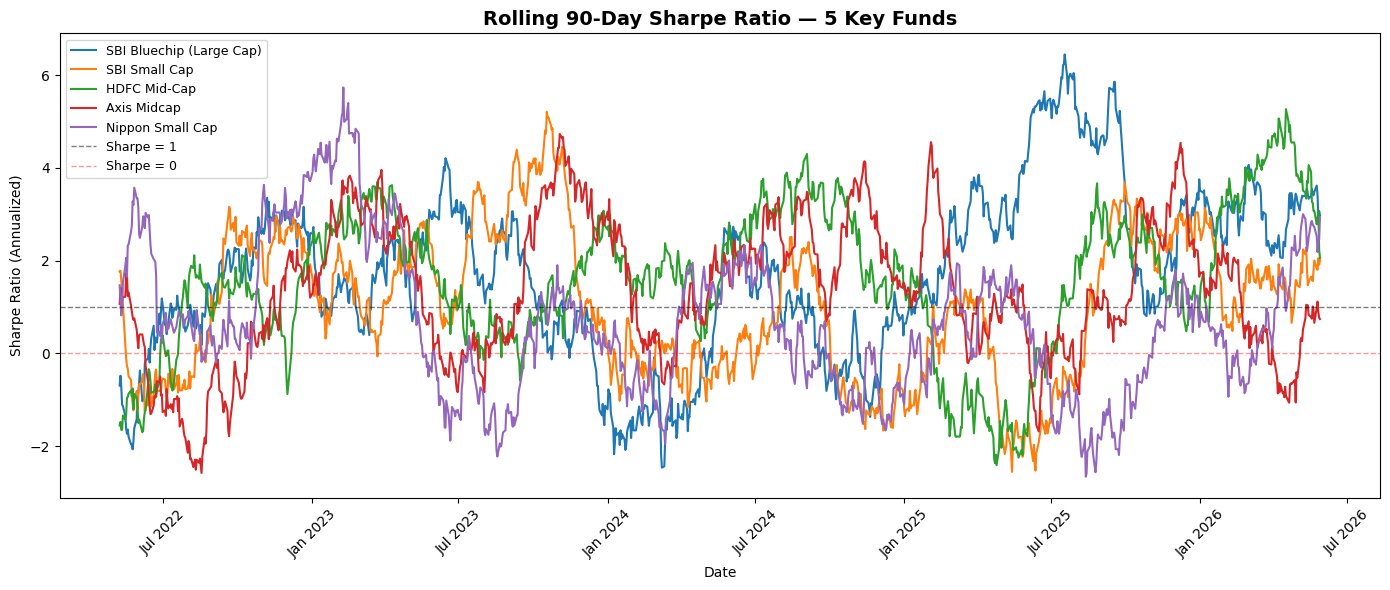

Chart saved!


In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 5 key funds select - one from each category
key_funds = {
    'SBI Bluechip (Large Cap)'  : 119551,
    'SBI Small Cap'             : 119598,
    'HDFC Mid-Cap'              : 100033,
    'Axis Midcap'               : 119094,
    'Nippon Small Cap'          : 118634
}

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for (label, code), color in zip(key_funds.items(), colors):
    fund_nav = nav_df[nav_df['amfi_code'] == code].copy()
    fund_nav = fund_nav.sort_values('date')
    
    returns = fund_nav['nav'].pct_change().dropna()
    returns.index = fund_nav['date'].iloc[1:]
    
    # Rolling 90-day Sharpe = (mean / std) * sqrt(252)
    roll_mean = returns.rolling(90).mean()
    roll_std  = returns.rolling(90).std()
    roll_sharpe = (roll_mean / roll_std) * (252 ** 0.5)
    
    ax.plot(returns.index, roll_sharpe, label=label, color=color, linewidth=1.5)

ax.axhline(y=1, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Sharpe = 1')
ax.axhline(y=0, color='red',   linestyle='--', linewidth=1, alpha=0.4, label='Sharpe = 0')
ax.set_title('Rolling 90-Day Sharpe Ratio — 5 Key Funds', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sharpe Ratio (Annualized)')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/rolling_sharpe_chart.png', dpi=150)
plt.show()
print("Chart saved!")

In [11]:
txn_df = pd.read_csv('../data/raw/08_investor_transactions.csv')
print(txn_df.columns.tolist())
print(txn_df.head(3))

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   

       state       city city_tier age_group  gender  annual_income_lakh  \
0  Telangana  Hyderabad       T30       56+  Female                77.1   
1     Punjab   Amritsar       B30     18-25    Male                 7.1   
2    Haryana  Faridabad       B30     36-45    Male                47.2   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verified  
2      Mandate   Verified  


In [13]:
# Filter only SIP transactions
sip_df = txn_df[txn_df['transaction_type'] == 'SIP'].copy()
sip_df['transaction_date'] = pd.to_datetime(sip_df['transaction_date'])

# First transaction year per investor = cohort
first_txn = sip_df.groupby('investor_id')['transaction_date'].min().reset_index()
first_txn['cohort_year'] = first_txn['transaction_date'].dt.year
sip_df = sip_df.merge(first_txn[['investor_id','cohort_year']], on='investor_id')

# Top fund preference per cohort
top_fund = (sip_df.groupby(['cohort_year','amfi_code'])['amount_inr']
            .sum().reset_index()
            .sort_values('amount_inr', ascending=False)
            .groupby('cohort_year').first()
            .reset_index()
            .rename(columns={'amfi_code':'top_fund_amfi'}))

# Cohort summary
cohort_df = sip_df.groupby('cohort_year').agg(
    total_investors = ('investor_id', 'nunique'),
    avg_sip_amount  = ('amount_inr', 'mean'),
    total_invested  = ('amount_inr', 'sum'),
    total_sip_txns  = ('investor_id', 'count')
).reset_index()

# Merge top fund
cohort_df = cohort_df.merge(top_fund[['cohort_year','top_fund_amfi']], on='cohort_year')
cohort_df['avg_sip_amount'] = cohort_df['avg_sip_amount'].round(2)

print(cohort_df)
cohort_df.to_csv('../data/processed/cohort_analysis.csv', index=False)
print("\nSaved to processed/cohort_analysis.csv ")

   cohort_year  total_investors  avg_sip_amount  total_invested  \
0         2024             4456        10986.86       212189262   
1         2025              306        12516.70         5044229   

   total_sip_txns  top_fund_amfi  
0           19313         125498  
1             403         119599  

Saved to processed/cohort_analysis.csv 


In [14]:
# SIP investors with 6+ transactions
sip_df['transaction_date'] = pd.to_datetime(sip_df['transaction_date'])
sip_counts = sip_df.groupby('investor_id')['transaction_date'].count()
eligible = sip_counts[sip_counts >= 6].index

# Compute avg gap between SIP dates
continuity = []
for inv in eligible:
    dates = sip_df[sip_df['investor_id'] == inv]['transaction_date'].sort_values()
    gaps  = dates.diff().dt.days.dropna()
    avg_gap = gaps.mean()
    continuity.append({
        'investor_id' : inv,
        'sip_count'   : len(dates),
        'avg_gap_days': round(avg_gap, 1),
        'at_risk'     : 'Yes' if avg_gap > 35 else 'No'
    })

cont_df = pd.DataFrame(continuity)
print(cont_df['at_risk'].value_counts())
print(f"\nTotal eligible investors: {len(cont_df)}")
print(cont_df.head(10))
cont_df.to_csv('../data/processed/sip_continuity.csv', index=False)
print("\nSaved ")

at_risk
Yes    1332
No       30
Name: count, dtype: int64

Total eligible investors: 1362
  investor_id  sip_count  avg_gap_days at_risk
0   INV000004          6          85.4     Yes
1   INV000008          6          70.4     Yes
2   INV000010          6          64.8     Yes
3   INV000011          7          40.2     Yes
4   INV000012          8          57.0     Yes
5   INV000013          7          55.3     Yes
6   INV000014          7          75.3     Yes
7   INV000023          8          58.6     Yes
8   INV000028          6          93.6     Yes
9   INV000029          7          60.7     Yes

Saved 


In [15]:
# Load scheme performance
perf_df = pd.read_csv('../data/raw/07_scheme_performance.csv')

def recommend_funds(risk_appetite):
    # Map user input to risk_grade
    risk_map = {
        'Low'      : ['Low'],
        'Moderate' : ['Moderate'],
        'High'     : ['High', 'Very High']
    }
    grades = risk_map.get(risk_appetite, [])
    filtered = perf_df[perf_df['risk_grade'].isin(grades)]
    top3 = (filtered.sort_values('sharpe_ratio', ascending=False)
                    .head(3)[['scheme_name','category','risk_grade',
                               'sharpe_ratio','return_3yr_pct']])
    print(f"\n--- Top 3 Funds for {risk_appetite} Risk Appetite ---")
    print(top3.to_string(index=False))

# Test all 3 risk levels
recommend_funds('Low')
recommend_funds('Moderate')
recommend_funds('High')


--- Top 3 Funds for Low Risk Appetite ---
                             scheme_name category risk_grade  sharpe_ratio  return_3yr_pct
ICICI Pru Liquid Fund - Regular - Growth   Liquid        Low          7.68            7.68
    Kotak Liquid Fund - Regular - Growth   Liquid        Low          6.18            6.18
     ABSL Liquid Fund - Regular - Growth   Liquid        Low          5.14            5.14

--- Top 3 Funds for Moderate Risk Appetite ---
                                  scheme_name  category risk_grade  sharpe_ratio  return_3yr_pct
    HDFC Top 100 Fund - Regular Plan - Growth Large Cap   Moderate          1.06           14.84
Mirae Asset Large Cap Fund - Regular - Growth Large Cap   Moderate          1.06           14.81
    ICICI Pru Bluechip Fund - Direct - Growth Large Cap   Moderate          1.03           14.41

--- Top 3 Funds for High Risk Appetite ---
                                  scheme_name  category risk_grade  sharpe_ratio  return_3yr_pct
Kotak Emerging E

In [16]:
# Save recommender.py to scripts folder
recommender_code = '''import pandas as pd
import os

def recommend_funds(risk_appetite, data_path='../data/raw/07_scheme_performance.csv'):
    perf_df = pd.read_csv(data_path)
    risk_map = {
        'Low'      : ['Low'],
        'Moderate' : ['Moderate'],
        'High'     : ['High', 'Very High']
    }
    grades = risk_map.get(risk_appetite, [])
    if not grades:
        print("Invalid input! Choose: Low / Moderate / High")
        return
    filtered = perf_df[perf_df['risk_grade'].isin(grades)]
    top3 = (filtered.sort_values('sharpe_ratio', ascending=False)
                    .head(3)[['scheme_name','category','risk_grade',
                               'sharpe_ratio','return_3yr_pct']])
    print(f"\\n--- Top 3 Funds for {risk_appetite} Risk Appetite ---")
    print(top3.to_string(index=False))

if __name__ == "__main__":
    user_input = input("Enter risk appetite (Low / Moderate / High): ")
    recommend_funds(user_input)
'''

with open('../scripts/recommender.py', 'w') as f:
    f.write(recommender_code)
print("recommender.py saved to scripts/ ")

recommender.py saved to scripts/ 


In [17]:
holdings_df = pd.read_csv('../data/raw/09_portfolio_holdings.csv')
print(holdings_df.columns.tolist())
print(holdings_df.head(3))

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
   amfi_code stock_symbol              stock_name       sector  weight_pct  \
0     119551    POWERGRID  Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK           HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM   Grasim Industries Ltd  Diversified        9.90   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  


In [19]:
# Filter equity funds only
equity_funds = perf_df[perf_df['category'].isin(
    ['Large Cap','Mid Cap','Small Cap','Flexi Cap','ELSS'])]['amfi_code'].tolist()

holdings_equity = holdings_df[holdings_df['amfi_code'].isin(equity_funds)].copy()

# HHI = sum of (weight_i / 100)^2 per fund
holdings_equity['weight_norm'] = holdings_equity['weight_pct'] / 100

hhi_df = (holdings_equity.groupby('amfi_code')
          .apply(lambda x: (x['weight_norm'] ** 2).sum())
          .reset_index()
          .rename(columns={0: 'hhi_score'}))

# Merge fund names
hhi_df = hhi_df.merge(perf_df[['amfi_code','scheme_name','category']], on='amfi_code')
hhi_df['hhi_score'] = hhi_df['hhi_score'].round(4)
hhi_df['concentration'] = hhi_df['hhi_score'].apply(
    lambda x: 'High' if x > 0.15 else ('Moderate' if x > 0.10 else 'Low'))

hhi_df = hhi_df.sort_values('hhi_score', ascending=False)
print(hhi_df[['scheme_name','category','hhi_score','concentration']].to_string(index=False))
hhi_df.to_csv('../data/processed/hhi_concentration.csv', index=False)
print("\nSaved ")

                                       scheme_name  category  hhi_score concentration
             Axis Bluechip Fund - Regular - Growth Large Cap     0.2064          High
            ABSL Small Cap Fund - Regular - Growth Small Cap     0.2007          High
         SBI Small Cap Fund - Direct Plan - Growth Small Cap     0.1748          High
    Nippon India Large Cap Fund - Regular - Growth Large Cap     0.1683          High
          ICICI Pru Midcap Fund - Regular - Growth   Mid Cap     0.1576          High
 HDFC Mid-Cap Opportunities Fund - Direct - Growth   Mid Cap     0.1524          High
            Kotak Bluechip Fund - Regular - Growth Large Cap     0.1497      Moderate
     Mirae Asset Tax Saver Fund - Regular - Growth      ELSS     0.1494      Moderate
HDFC Mid-Cap Opportunities Fund - Regular - Growth   Mid Cap     0.1476      Moderate
                DSP Midcap Fund - Regular - Growth   Mid Cap     0.1416      Moderate
        ICICI Pru Bluechip Fund - Regular - Growth Lar

# 📊 Advanced Analytics — Key Insights

## 1. Highest Risk Funds by VaR
Small Cap funds show worst VaR at 95% confidence (~-2.6% daily),
meaning on bad days investors can lose 2.6% in a single day.
CVaR of ~-3.2% indicates average loss on worst 5% days is even steeper.
Liquid funds are safest with VaR of just -0.15%.

## 2. Investor Cohort Investing Patterns
2024 cohort is the largest with 4,456 investors and ₹21.2 Cr total invested.
Newer 2025 cohort has higher avg SIP (₹12,517 vs ₹10,987) suggesting
more financially aware investors are entering mutual funds recently.

## 3. SIP Continuity — At-Risk Investors
Out of 1,362 investors with 6+ SIP transactions, 1,332 (97%) are flagged
as at-risk with avg gap > 35 days. This suggests most investors are
irregular with SIP payments — a major retention risk for the AMC.

## 4. Rolling Sharpe Ratio Trends
Small Cap funds show highly volatile Sharpe ratios, swinging negative
during market downturns to 2.0+ during bull runs. Large Cap funds maintain
stable Sharpe around 0.8–1.2, confirming lower risk-adjusted volatility.

## 5. Sector Concentration (HHI)
Axis Bluechip (HHI=0.2064) and ABSL Small Cap (HHI=0.2007) are the most
concentrated funds. Investors seeking diversification should prefer funds
with HHI < 0.10. High HHI funds carry hidden concentration risk even
within the same asset class.